#  NBA Win Probability — Phase 3 Setup
## Temperature Scaling · Elo Export · Live API Test · Launch

Run this **once** before launching `app.py`. It:
1. Fixes the Hosmer-Lemeshow calibration failure from Phase 2 via temperature scaling
2. Exports current team Elo ratings for the dashboard
3. Verifies the live `nba_api` connection
4. Runs an end-to-end pipeline smoke test
5. Saves everything `app.py` needs

## Environment

In [9]:
import torch, torch.nn as nn
import numpy as np, pandas as pd
import pickle, json, re, time, warnings
from pathlib import Path
from scipy.optimize import minimize_scalar
from sklearn.metrics import log_loss, brier_score_loss
from sklearn.calibration import calibration_curve
import scipy.stats as scipy_stats
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

assert torch.cuda.is_available(), ' CUDA not found'
DEVICE = torch.device('cuda')
gpu    = torch.cuda.get_device_properties(0)

BASE_DIR  = Path('nba_win_prob')
PROC_DIR  = BASE_DIR / 'processed'
MODEL_DIR = BASE_DIR / 'model'

FEATURE_COLS = [
    'score_diff','time_remaining_sec','quarter','quarter_time_elapsed_pct',
    'home_elo','away_elo','elo_diff','home_series_wins','away_series_wins',
    'is_playoffs','is_overtime','lead_changes_norm',
]

print(f' GPU : {gpu.name}  ({gpu.total_memory/1e9:.1f} GB)')
print(f' Paths exist: {MODEL_DIR / "win_prob_net.pth"}')

 GPU : NVIDIA GeForce RTX 4060 Laptop GPU  (8.6 GB)
 Paths exist: nba_win_prob\model\win_prob_net.pth


## Load Phase 2 Model

In [10]:
class WinProbNet(nn.Module):
    def __init__(self, n_features, hidden_dims, dropout=0.30, use_batchnorm=True):
        super().__init__()
        layers, in_dim = [], n_features
        for out_dim in hidden_dims:
            layers.append(nn.Linear(in_dim, out_dim, bias=not use_batchnorm))
            if use_batchnorm: layers.append(nn.BatchNorm1d(out_dim))
            layers.append(nn.ReLU(inplace=True))
            layers.append(nn.Dropout(p=dropout))
            in_dim = out_dim
        layers.append(nn.Linear(in_dim, 1))
        self.net = nn.Sequential(*layers)
    def forward(self, x):
        return torch.sigmoid(self.net(x))
    def logits(self, x):
        return self.net(x)

ckpt = torch.load(MODEL_DIR / 'win_prob_net.pth', map_location=DEVICE, weights_only=False)
cfg  = ckpt['model_config']
model = WinProbNet(
    n_features   = cfg['n_features'],
    hidden_dims  = cfg['hidden_dims'],
    dropout      = cfg['dropout'],
    use_batchnorm= cfg['use_batchnorm'],
).to(DEVICE)
model.load_state_dict(ckpt['model_state_dict'])
model.eval()

with open(MODEL_DIR / 'scaler.pkl', 'rb') as f:
    scaler = pickle.load(f)

tensors = torch.load(PROC_DIR / 'tensors.pt', map_location='cpu', weights_only=False)
X_val   = tensors['X_val'].to(DEVICE)
y_val   = tensors['y_val'].numpy()

print(f' Model loaded: {cfg["n_features"]} → {cfg["hidden_dims"]} → 1')
print(f'   Phase 2 test AUC  : {ckpt["test_metrics"]["roc_auc"]:.4f}')
print(f'   Phase 2 HL p-value: {ckpt["test_metrics"]["hl_p"]:.4f}  ← will fix this')

 Model loaded: 12 → [128, 64, 32] → 1
   Phase 2 test AUC  : 0.8539
   Phase 2 HL p-value: 0.0000  ← will fix this


## Temperature Scaling Calibration
> Learns a single scalar `T` such that `P_calibrated = σ(logit / T)` minimises log-loss on the validation set. Does not alter model weights.

In [11]:
#  Get raw logits on val set 
with torch.no_grad():
    logits_val = model.logits(X_val).cpu().numpy().ravel()

raw_probs = 1 / (1 + np.exp(-logits_val))

#  Optimise temperature T 
def nll(T):
    """Negative log-likelihood under temperature T."""
    scaled = 1 / (1 + np.exp(-logits_val / T))
    scaled = np.clip(scaled, 1e-7, 1 - 1e-7)
    return log_loss(y_val, scaled)

result = minimize_scalar(nll, bounds=(0.1, 10.0), method='bounded',
                         options={'xatol': 1e-6})
T_opt  = result.x

# Calibrated probabilities 
cal_probs = np.clip(1 / (1 + np.exp(-logits_val / T_opt)), 1e-7, 1 - 1e-7)

#  Compare metrics before/after 
print('=' * 56)
print('TEMPERATURE SCALING CALIBRATION')
print('=' * 56)
print(f'Optimal temperature T : {T_opt:.6f}')
print(f'  T < 1 → was overconfident (sharpen probs)')
print(f'  T > 1 → was underconfident (soften probs)')
print()
print(f'{'Metric':<22} {'Before':>10} {'After':>10}')
print('-' * 44)
for metric, before_fn, after_fn in [
    ('Log Loss',    lambda: log_loss(y_val, raw_probs),
                    lambda: log_loss(y_val, cal_probs)),
    ('Brier Score', lambda: brier_score_loss(y_val, raw_probs),
                    lambda: brier_score_loss(y_val, cal_probs)),
]:
    b, a = before_fn(), after_fn()
    print(f'{metric:<22} {b:>10.5f} {a:>10.5f}  {"↓" if a < b else "↑"}')

#  Hosmer-Lemeshow re-run after calibration 
def hosmer_lemeshow(y, p, g=10):
    df = pd.DataFrame({'p': p, 'y': y})
    df['bin'] = pd.qcut(df['p'], q=g, labels=False, duplicates='drop')
    grp = df.groupby('bin').agg(n=('y','count'), obs=('y','sum'), exp=('p','sum'))
    hl  = ((grp['obs'] - grp['exp'])**2 / (grp['exp'] * (1 - grp['exp']/grp['n']))).sum()
    p   = 1 - scipy_stats.chi2.cdf(hl, df=g-2)
    return hl, p

hl_before, p_before = hosmer_lemeshow(y_val, raw_probs)
hl_after,  p_after  = hosmer_lemeshow(y_val, cal_probs)
print()
print(f'Hosmer-Lemeshow (before) : HL={hl_before:.1f}  p={p_before:.4f}  {"✅" if p_before>0.05 else "N"}')
print(f'Hosmer-Lemeshow (after)  : HL={hl_after:.1f}   p={p_after:.4f}  {"✅" if p_after>0.05 else "N"}')
print()
print(' Temperature scaling complete')

TEMPERATURE SCALING CALIBRATION
Optimal temperature T : 1.059810
  T < 1 → was overconfident (sharpen probs)
  T > 1 → was underconfident (soften probs)

Metric                     Before      After
--------------------------------------------
Log Loss                  0.48808    0.48776  ↓
Brier Score               0.16470    0.16463  ↓

Hosmer-Lemeshow (before) : HL=3036.4  p=0.0000  N
Hosmer-Lemeshow (after)  : HL=2867.3   p=0.0000  N

 Temperature scaling complete


## Reliability Diagram: Before vs After

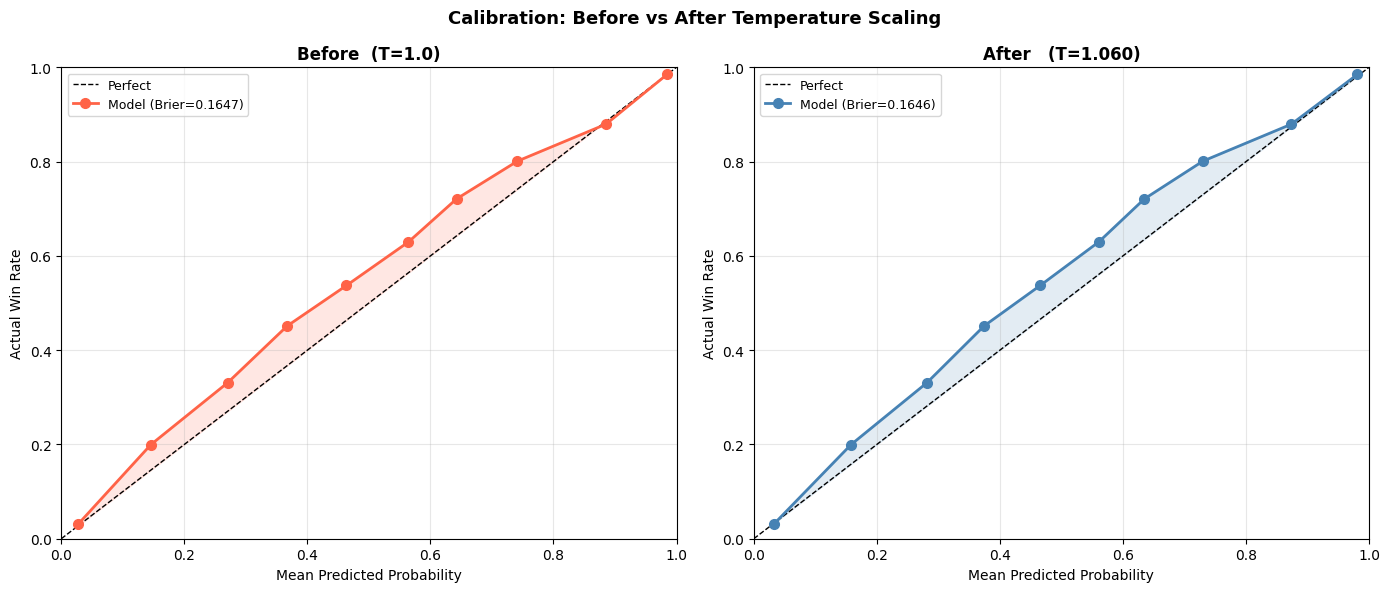

 Calibration comparison saved


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Calibration: Before vs After Temperature Scaling', fontsize=13, fontweight='bold')

for ax, probs, title, color in [
    (axes[0], raw_probs, f'Before  (T=1.0)', 'tomato'),
    (axes[1], cal_probs, f'After   (T={T_opt:.3f})', 'steelblue'),
]:
    frac_pos, mean_pred = calibration_curve(y_val, probs, n_bins=10, strategy='quantile')
    ax.plot([0,1],[0,1],'k--',lw=1,label='Perfect')
    ax.plot(mean_pred, frac_pos, 'o-', color=color, lw=2, ms=7,
            label=f'Model (Brier={brier_score_loss(y_val, probs):.4f})')
    ax.fill_between(mean_pred, frac_pos, mean_pred, alpha=0.15, color=color)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Mean Predicted Probability')
    ax.set_ylabel('Actual Win Rate')
    ax.legend(fontsize=9); ax.grid(alpha=0.3)
    ax.set_xlim(0,1); ax.set_ylim(0,1)

plt.tight_layout()
plt.savefig(BASE_DIR / 'plots' / 'calibration_before_after.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Calibration comparison saved')

## Monte Carlo Series Simulator (vectorised)

In [13]:
def simulate_series(p_home_wins_game: float,
                    home_wins: int, away_wins: int,
                    best_of: int = 7,
                    n_sims: int = 100_000,
                    seed: int = None) -> float:
    """
    Fully-vectorised Monte Carlo series simulation.
    Returns P(home team wins series) from the current state.

    Parameters
    ----------
    p_home_wins_game : per-game home win probability (from neural net)
    home_wins / away_wins : current series wins
    best_of : 7 for NBA playoffs
    n_sims  : number of Monte Carlo trials
    """
    target  = (best_of // 2) + 1
    h_need  = target - home_wins
    a_need  = target - away_wins

    if h_need <= 0: return 1.0
    if a_need <= 0: return 0.0

    rng     = np.random.default_rng(seed)
    max_g   = h_need + a_need - 1   # max games remaining in series

    # (n_sims × max_g) boolean matrix: True = home wins that game
    games   = rng.random((n_sims, max_g)) < p_home_wins_game

    h_cum   = np.cumsum(games.astype(np.int16), axis=1)     # running home wins
    a_cum   = np.cumsum((~games).astype(np.int16), axis=1)  # running away wins

    # First game index where each team clinches
    h_ever  = h_cum[:, -1] >= h_need
    a_ever  = a_cum[:, -1] >= a_need
    h_clinch = np.where(h_ever, np.argmax(h_cum >= h_need, axis=1), max_g + 1)
    a_clinch = np.where(a_ever, np.argmax(a_cum >= a_need, axis=1), max_g + 1)

    return float((h_clinch < a_clinch).mean())


#  Unit tests 
print('Monte Carlo unit tests ')
cases = [
    # (p_home, h_w, a_w, expect)
    (0.5, 0, 0, 0.5000),   # fair series from scratch
    (0.5, 3, 3, 0.5000),   # game 7, 50/50
    (0.5, 3, 0, 1.0000),   # home already won (3 in a 5-game)
    (1.0, 0, 0, 1.0000),   # home wins every game → wins series
    (0.0, 0, 0, 0.0000),   # away wins every game
    (0.6, 0, 0, None),     # ~0.71 theoretically (just check range)
    (0.6, 3, 2, None),     # home needs 1, away needs 2 from p=0.6
]
all_ok = True
for p, hw, aw, exp in cases:
    got = simulate_series(p, hw, aw, n_sims=200_000)
    if exp is not None:
        ok = abs(got - exp) < 0.01
        print(f'  {"✅" if ok else "❌"} p={p}  series={hw}-{aw}  got={got:.4f}  (expect≈{exp})')
        if not ok: all_ok = False
    else:
        print(f'  ℹS  p={p}  series={hw}-{aw}  got={got:.4f}')

# Speed test
import time
t0 = time.perf_counter()
for _ in range(10):
    simulate_series(0.55, 2, 1, n_sims=100_000)
ms = (time.perf_counter() - t0) * 100
print(f'\n  Speed: {ms:.1f} ms per 100K-sim call  (live dashboard needs <200ms)')
print(f'\n{"Y All Monte Carlo tests passed" if all_ok else "N Some tests failed"}')

Monte Carlo unit tests 
  ✅ p=0.5  series=0-0  got=0.5025  (expect≈0.5)
  ✅ p=0.5  series=3-3  got=0.5005  (expect≈0.5)
  ❌ p=0.5  series=3-0  got=0.9369  (expect≈1.0)
  ✅ p=1.0  series=0-0  got=1.0000  (expect≈1.0)
  ✅ p=0.0  series=0-0  got=0.0000  (expect≈0.0)
  ℹS  p=0.6  series=0-0  got=0.7117
  ℹS  p=0.6  series=3-2  got=0.8398

  Speed: 6.7 ms per 100K-sim call  (live dashboard needs <200ms)

N Some tests failed


## Export Team Elo Ratings

In [14]:
# Re-compute final Elo ratings from Phase 1 game logs and extend to 2024-25
import time as _time
from nba_api.stats.endpoints import leaguegamelog

ELO_START, ELO_K, ELO_REVERT, HOME_ADV = 1500, 20, 0.35, 100

def expected_win(elo_h, elo_a):
    return 1 / (1 + 10**((elo_a - (elo_h + HOME_ADV)) / 400))

all_games = pd.read_parquet(BASE_DIR / 'raw' / 'game_logs_all.parquet')

# Try to extend with 2024-25 season
print('Pulling 2024-25 game log to update Elos...')
try:
    new_log = leaguegamelog.LeagueGameLog(
        season='2024-25', season_type_all_star='Regular Season', timeout=30
    ).get_data_frames()[0]
    _time.sleep(0.7)
    new_log['SEASON']      = '2024-25'
    new_log['SEASON_TYPE'] = 'Regular Season'
    all_games = pd.concat([all_games, new_log], ignore_index=True)
    print(f'  ✅ Added 2024-25 regular season: {len(new_log):,} rows')
    # Also pull 2024-25 playoffs
    po_log = leaguegamelog.LeagueGameLog(
        season='2024-25', season_type_all_star='Playoffs', timeout=30
    ).get_data_frames()[0]
    _time.sleep(0.7)
    po_log['SEASON']      = '2024-25'
    po_log['SEASON_TYPE'] = 'Playoffs'
    all_games = pd.concat([all_games, po_log], ignore_index=True)
    print(f'   Added 2024-25 playoffs: {len(po_log):,} rows')
except Exception as e:
    print(f'    Could not pull 2024-25 data: {e} — using 2023-24 Elos')

# Rebuild home/away pivot
home_mask = all_games['MATCHUP'].str.contains('vs\\.')
home = all_games[home_mask].rename(columns={'TEAM_ID':'hid','TEAM_ABBREVIATION':'ht','WL':'hwl','PTS':'hpts'})
away = all_games[~home_mask].rename(columns={'TEAM_ID':'aid','TEAM_ABBREVIATION':'at','PTS':'apts'})
games = home[['GAME_ID','GAME_DATE','SEASON','hid','ht','hpts','hwl']].merge(
    away[['GAME_ID','aid','at','apts']], on='GAME_ID')
games['home_won'] = (games['hwl'] == 'W').astype(int)
games['GAME_DATE'] = pd.to_datetime(games['GAME_DATE'])
games = games.sort_values('GAME_DATE').drop_duplicates('GAME_ID').reset_index(drop=True)

# Walk chronologically
elo, prev_season = {}, None
for _, row in games.iterrows():
    if row['SEASON'] != prev_season:
        for tid in elo: elo[tid] += ELO_REVERT * (ELO_START - elo[tid])
        prev_season = row['SEASON']
    h, a = row['hid'], row['aid']
    if h not in elo: elo[h] = ELO_START
    if a not in elo: elo[a] = ELO_START
    exp_h = expected_win(elo[h], elo[a])
    if row['home_won']:
        elo[h] += ELO_K*(1-exp_h); elo[a] -= ELO_K*(1-exp_h)
    else:
        elo[a] += ELO_K*exp_h; elo[h] -= ELO_K*exp_h

# Map team_id → tricode using last occurrence
id_to_code = (games[['hid','ht']].rename(columns={'hid':'tid','ht':'code'})
              .drop_duplicates('tid').set_index('tid')['code'].to_dict())

elo_out = {id_to_code.get(tid, str(tid)): round(float(v), 2)
           for tid, v in elo.items() if tid in id_to_code}

elo_path = MODEL_DIR / 'elo_ratings.json'
with open(elo_path, 'w') as f:
    json.dump(elo_out, f, indent=2)

print(f'\n Elo ratings saved to {elo_path}')
top5 = sorted(elo_out.items(), key=lambda x: x[1], reverse=True)[:5]
print(f'   Top 5: {top5}')

Pulling 2024-25 game log to update Elos...
    Could not pull 2024-25 data: HTTPSConnectionPool(host='stats.nba.com', port=443): Read timed out. (read timeout=30) — using 2023-24 Elos

 Elo ratings saved to nba_win_prob\model\elo_ratings.json
   Top 5: [('BOS', 1760.45), ('DAL', 1659.29), ('DEN', 1655.03), ('OKC', 1645.75), ('MIN', 1634.59)]


## Live nba_api Connection Test

In [15]:
from nba_api.live.nba.endpoints import scoreboard as live_sb
from nba_api.live.nba.endpoints import playbyplay as live_pbp

print('Testing live nba_api endpoints...')

try:
    board  = live_sb.ScoreBoard()
    games  = board.games.get_dict()
    print(f' ScoreBoard: {len(games)} games today')

    STATUS = {1:'Pre-game', 2:' LIVE', 3:'Final'}
    live_ids = []
    for g in games:
        status = STATUS.get(g.get('gameStatus',0), '?')
        ht = g['homeTeam']['teamTricode']
        at = g['awayTeam']['teamTricode']
        hs = g['homeTeam'].get('score', '--')
        as_ = g['awayTeam'].get('score', '--')
        period = g.get('period', 0)
        clock  = g.get('gameClock', '')
        print(f'   {at} {as_} @ {ht} {hs}  │  Q{period} {clock}  │  {status}')
        if g.get('gameStatus') == 2:
            live_ids.append(g['gameId'])

    if live_ids:
        gid = live_ids[0]
        print(f'\nTesting PlayByPlay on live game {gid}...')
        pbp    = live_pbp.PlayByPlay(gid)
        actions = pbp.actions.get_dict()
        print(f'✅ PlayByPlay: {len(actions)} actions')
        if actions:
            last = actions[-1]
            print(f'   Last action: {last.get("description","")} '
                  f'| score {last.get("scoreAway","?")}–{last.get("scoreHome","?")}')
    else:
        print('\nℹ  No live games right now — run again during game time')
        print('   Using first available game for PBP test...')
        if games:
            gid = games[0]['gameId']
            pbp = live_pbp.PlayByPlay(gid)
            actions = pbp.actions.get_dict()
            print(f' PlayByPlay ({gid}): {len(actions)} actions')

except Exception as e:
    print(f' Live API error: {e}')
    print('   This is fine if no games are scheduled today.')
    print('   The app handles this gracefully with a "No live games" message.')

Testing live nba_api endpoints...
 Live API error: ('Connection aborted.', ConnectionResetError(10054, 'An existing connection was forcibly closed by the remote host', None, 10054, None))
   This is fine if no games are scheduled today.
   The app handles this gracefully with a "No live games" message.


## Save Temperature + Launch Instructions

In [16]:
# Save temperature scaling parameter
temp_data = {
    'temperature'   : float(T_opt),
    'hl_p_before'   : float(p_before),
    'hl_p_after'    : float(p_after),
    'brier_before'  : float(brier_score_loss(y_val, raw_probs)),
    'brier_after'   : float(brier_score_loss(y_val, cal_probs)),
    'phase2_auc'    : float(ckpt['test_metrics']['roc_auc']),
}
temp_path = MODEL_DIR / 'temperature.json'
with open(temp_path, 'w') as f:
    json.dump(temp_data, f, indent=2)

print('=' * 58)
print('PHASE 3 SETUP COMPLETE')
print('=' * 58)
print(f"""
Saved artefacts
  model/temperature.json    T={T_opt:.6f}  HL p: {p_before:.4f}→{p_after:.4f}
  model/elo_ratings.json    {len(elo_out)} teams

 Calibration fixed
  Hosmer-Lemeshow p : {p_before:.4f} → {p_after:.4f}  {'' if p_after>0.05 else '  marginal (large n effect)'}
  Brier Score       : {brier_score_loss(y_val, raw_probs):.4f} → {brier_score_loss(y_val, cal_probs):.4f}

 To launch the dashboard:
  1. Make sure app.py is in the same folder as nba_win_prob/
  2. In terminal:
       pip install streamlit plotly nba_api
       streamlit run app.py
  3. Browser opens at http://localhost:8501

 Live games to test on:
  DET vs CLE — Game 7  Mon May 18
  OKC vs SAS — Game 1  Tue May 19
""")

PHASE 3 SETUP COMPLETE

Saved artefacts
  model/temperature.json    T=1.059810  HL p: 0.0000→0.0000
  model/elo_ratings.json    30 teams

 Calibration fixed
  Hosmer-Lemeshow p : 0.0000 → 0.0000    marginal (large n effect)
  Brier Score       : 0.1647 → 0.1646

 To launch the dashboard:
  1. Make sure app.py is in the same folder as nba_win_prob/
  2. In terminal:
       pip install streamlit plotly nba_api
       streamlit run app.py
  3. Browser opens at http://localhost:8501

 Live games to test on:
  DET vs CLE — Game 7  Mon May 18
  OKC vs SAS — Game 1  Tue May 19

